# A. Data Exploration


---

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 30)

conn = sqlite3.connect('../data/olist.db')

# Quick check: row counts per table
row_counts = pd.read_sql("""
    SELECT 'orders'        AS tbl, COUNT(*) AS rows FROM orders
    UNION ALL SELECT 'order_items',     COUNT(*) FROM order_items
    UNION ALL SELECT 'order_payments',  COUNT(*) FROM order_payments
    UNION ALL SELECT 'order_reviews',   COUNT(*) FROM order_reviews
    UNION ALL SELECT 'products',        COUNT(*) FROM products
    UNION ALL SELECT 'sellers',         COUNT(*) FROM sellers
    UNION ALL SELECT 'customers',       COUNT(*) FROM customers
""", conn)
print(row_counts.to_string(index=False))

           tbl   rows
        orders  99441
   order_items 112650
order_payments 103886
 order_reviews  99224
      products  32951
       sellers   3095
     customers  99441


## 1. Orders table

In [2]:
orders = pd.read_sql("SELECT * FROM orders LIMIT 5", conn)
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
# Order status distribution
status_dist = pd.read_sql("""
    SELECT order_status, COUNT(*) AS n,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 1) AS pct
    FROM orders
    GROUP BY order_status
    ORDER BY n DESC
""", conn)
print(status_dist.to_string(index=False))

order_status     n  pct
   delivered 96478 97.0
     shipped  1107  1.1
    canceled   625  0.6
 unavailable   609  0.6
    invoiced   314  0.3
  processing   301  0.3
     created     5  0.0
    approved     2  0.0


## 2. Data quality checks

In [4]:
# Null rates in key date columns
nulls = pd.read_sql("""
    SELECT
        COUNT(*) AS total_delivered,
        SUM(CASE WHEN order_approved_at IS NULL THEN 1 ELSE 0 END) AS null_approved,
        SUM(CASE WHEN order_delivered_carrier_date IS NULL THEN 1 ELSE 0 END) AS null_carrier,
        SUM(CASE WHEN order_delivered_customer_date IS NULL THEN 1 ELSE 0 END) AS null_customer,
        SUM(CASE WHEN order_estimated_delivery_date IS NULL THEN 1 ELSE 0 END) AS null_estimate
    FROM orders
    WHERE order_status = 'delivered'
""", conn)
print(nulls.T.to_string(header=False))

total_delivered  96478
null_approved       14
null_carrier         2
null_customer        8
null_estimate        0


## 3. Build the Analytical Base Table (ABT)

In [5]:
# Read the ABT query from the SQL file

ABT_QUERY = open('../sql/queries.sql').read().split('-- ----- 2.')[1].split('-- ----- 3.')[0]
# Strip the header line
ABT_QUERY = ABT_QUERY.split('\n', 3)[-1]

abt = pd.read_sql(ABT_QUERY, conn)
print(f'ABT shape: {abt.shape}')
abt.head(3)

ABT shape: (96478, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,hours_to_approval,hours_approval_to_carrier,hours_carrier_to_customer,hours_total_delivery,is_late,days_vs_estimate,n_items,total_price,total_freight,n_sellers,primary_category,seller_state,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,0.2,56.8,145.5,202.5,0,-7.1,1,29.99,8.72,1,housewares,SP,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,30.7,11.1,288.9,330.8,0,-5.4,1,118.70,22.76,1,perfumery,SP,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,0.3,4.9,220.3,225.5,0,-17.2,1,159.90,19.22,1,auto,SP,GO,5.0


## 4. Baseline delivery metrics

In [6]:
print(f"Total delivered orders:  {len(abt):,}")
print(f"Late delivery rate:      {abt['is_late'].mean():.1%}")
print(f"Avg total delivery hrs:  {abt['hours_total_delivery'].median():.0f} (median)")
print(f"Avg days vs estimate:    {abt['days_vs_estimate'].median():.1f} (median, negative=early)")
print()
print("Stage durations (median hours):")
for col in ['hours_to_approval', 'hours_approval_to_carrier', 'hours_carrier_to_customer']:
    print(f"  {col:<30s} {abt[col].median():>8.1f}")

Total delivered orders:  96,478
Late delivery rate:      8.1%
Avg total delivery hrs:  245 (median)
Avg days vs estimate:    -11.9 (median, negative=early)

Stage durations (median hours):
  hours_to_approval                   0.3
  hours_approval_to_carrier          43.6
  hours_carrier_to_customer         170.4


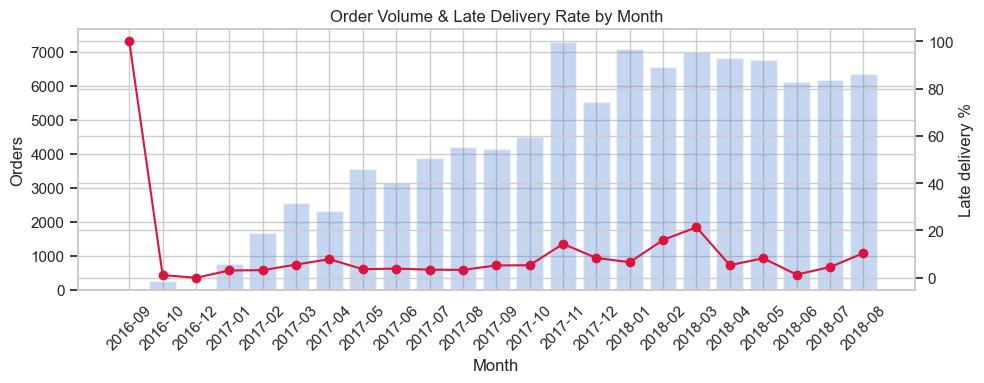

In [7]:
# Late delivery rate over time
abt['order_month'] = pd.to_datetime(abt['order_purchase_timestamp']).dt.to_period('M')

monthly = abt.groupby('order_month').agg(
    orders=('order_id', 'count'),
    late_rate=('is_late', 'mean')
).reset_index()
monthly['order_month'] = monthly['order_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(monthly['order_month'], monthly['orders'], alpha=0.3, label='Order volume')
ax2.plot(monthly['order_month'], monthly['late_rate'] * 100, 'o-', color='crimson', label='Late %')
ax1.set_xlabel('Month')
ax1.set_ylabel('Orders')
ax2.set_ylabel('Late delivery %')
plt.title('Order Volume & Late Delivery Rate by Month')
ax1.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.savefig('../output/01_monthly_late_rate.png', dpi=150)
plt.show()

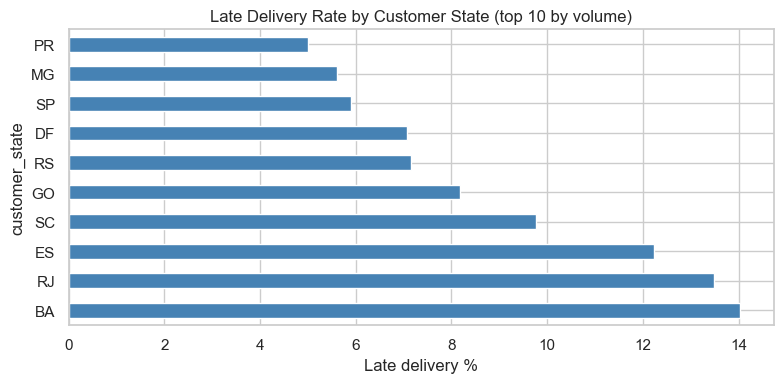

In [8]:
# Late rate by customer state
top_states = abt['customer_state'].value_counts().head(10).index
state_late = (abt[abt['customer_state'].isin(top_states)]
    .groupby('customer_state')['is_late'].mean()
    .sort_values(ascending=False) * 100)

state_late.plot.barh(figsize=(8, 4), color='steelblue')
plt.xlabel('Late delivery %')
plt.title('Late Delivery Rate by Customer State (top 10 by volume)')
plt.tight_layout()
plt.savefig('../output/01_late_by_state.png', dpi=150)
plt.show()

In [9]:
# Relationship: late delivery → bad reviews
review_by_late = abt.groupby('is_late')['review_score'].value_counts(normalize=True).unstack()
print("Review score distribution:")
print("(0 = on time, 1 = late)")
print(review_by_late.round(3))

Review score distribution:
(0 = on time, 1 = late)
review_score    1.0    2.0    3.0    4.0    5.0
is_late                                        
0             0.066  0.026  0.080  0.204  0.624
1             0.462  0.079  0.113  0.123  0.222


In [12]:
conn.close()
print('\nNotebook complete.')


Notebook complete.
